In [62]:
import sys 
sys.path.append('../..')

import jax
from functools import partial
from jax import grad, jacfwd, vmap, jit, hessian, value_and_grad
from jax.lax import scan
# from jax.ops import index_update, index
import jax.random as jnp_random
import jax.numpy as np

from jax.flatten_util import ravel_pytree

import numpy as onp
from time_opt_erg_lib.ergodic_metric import ErgodicMetric
from time_opt_erg_lib.fourier_utils import BasisFunc, get_phik, get_ck, recon_from_fourier
from IPython.display import clear_output
import matplotlib.pyplot as plt

from time_opt_erg_lib.opt_solver import AugmentedLagrangeSolver
from time_opt_erg_lib.target_distribution import TargetDistribution
import yaml
import pickle as pkl


In [63]:
class UniformDistr(object):
    def __init__(self) -> None:
        self.n = 2
        self.domain = np.meshgrid(
            *[np.linspace(0,1)]*self.n
        )
        self._s = np.stack([X.ravel() for X in self.domain]).T
        self.evals = (
            vmap(self.p)(self._s) , self._s
        )
    
    def plot(self):
        plt.contour(self.domain[0], self.domain[1], self.evals[0].reshape(self.domain[0].shape))

    def p(self, x):
        return 1.0

    def update(self):
        pass
class GaussianDistr(object):
    def __init__(self) -> None:
        self.n = 2
        self.domain = np.meshgrid(
            *[np.linspace(0,1)]*self.n
        )
        self._s = np.stack([X.ravel() for X in self.domain]).T
        _evals = vmap(self.p)(self._s)
        self.evals = (
            _evals/_evals.sum() , self._s
        )
    
    def plot(self):
        plt.contour(self.domain[0], self.domain[1], self.evals[0].reshape(self.domain[0].shape))

    def p(self, x):
        return np.exp(-150.5 * np.sum((x[:2] - 1)**2))
        # return 1
        # return np.exp(-60.5 * np.sum((x[:2] - 0.2)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - 0.75)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.2, 0.75]))**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.75, 0.2]))**2))
    def update(self):
        pass

class RevGaussianDistr(object):
    def __init__(self) -> None:
        self.n = 2
        self.domain = np.meshgrid(
            *[np.linspace(0,1)]*self.n
        )
        self._s = np.stack([X.ravel() for X in self.domain]).T
        _evals = vmap(self.p)(self._s)
        self.evals = (
            _evals/_evals.sum() , self._s
        )
    
    def plot(self):
        plt.contour(self.domain[0], self.domain[1], self.evals[0].reshape(self.domain[0].shape))

    def p(self, x):
        return 1 - np.exp(-150.5 * np.sum((x[:2] - 1)**2)) 
        # return 1
        # return np.exp(-60.5 * np.sum((x[:2] - 0.2)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - 0.75)**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.2, 0.75]))**2)) \
        #             + np.exp(-60.5 * np.sum((x[:2] - np.array([0.75, 0.2]))**2))
    def update(self):
        pass

In [64]:
def get_phik(vals, basis):
    _phi, _x = vals 
    phik = np.dot(_phi, vmap(basis.fk_vmap)(_x))
    phik = phik/phik[0]
    phik = phik/basis.hk_list
    return phik
def get_ck(trajectory, basis, tf, dt):
    ck = np.sum(vmap(basis.fk_vmap)(trajectory), axis=0)
    ck = ck / ck[0]
    ck = ck / basis.hk_list
    return ck

In [65]:
basis       = BasisFunc([10]*2)
metric      = ErgodicMetric(basis)
unif        = UniformDistr()
gauss       = GaussianDistr()
rev_gauss       = RevGaussianDistr()

# zero_distr  = (unif.evals[0]*0, unif.evals[1])
# zero_phik   = get_phik(zero_distr, basis)
unif_phik   = get_phik(unif.evals, basis)
gauss_phik  = get_phik(gauss.evals, basis)
rev_gauss_phik  = get_phik(rev_gauss.evals, basis)



In [66]:
np.sum(rev_gauss.evals[0] + gauss.evals[0]), metric(rev_gauss_phik, gauss_phik)

(Array(2.0000005, dtype=float32), Array(3.8030212, dtype=float32))

In [68]:
metric(unif_phik, 0*gauss_phik) + 2*metric(gauss_phik, 0*gauss_phik)

Array(10.539089, dtype=float32)

In [59]:
metric(rev_gauss_phik, 0*gauss_phik)

Array(1.0002348, dtype=float32)

In [57]:
metric(0*rev_gauss_phik, gauss_phik)

Array(4.7694564, dtype=float32)

In [58]:
metric(unif_phik, unif_phik*0)

Array(1.0001762, dtype=float32)

In [34]:
def loss(params):
    x1 = params['x1']
    x2 = params['x2']
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2.reshape((1,-1)), basis, 1, 1) 
    return metric(gauss_phik, ck2)

def upper_bound(params):
    x1 = params['x1']
    x2 = params['x2']
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2.reshape((1,-1)), basis, 1, 1) 
    return metric(unif_phik, 2*ck1), metric(unif_phik, 2*ck2) 


params = {
    'x1' : np.array([0.2,0.3]),
    'x2' : np.array([0.8,0.7])
}

for _ in range(100):
    d_params = grad(loss)(params)
    params['x1'] = params['x1'] + 0.001*d_params['x1']
    params['x2'] = params['x2'] + 0.001*d_params['x2']
    print(loss(params), upper_bound(params))

3.8658872 (Array(6.387534, dtype=float32), Array(6.457903, dtype=float32))
3.8906817 (Array(6.387534, dtype=float32), Array(6.5341663, dtype=float32))
3.9172604 (Array(6.387534, dtype=float32), Array(6.617294, dtype=float32))
3.9458785 (Array(6.387534, dtype=float32), Array(6.7082753, dtype=float32))
3.9767807 (Array(6.387534, dtype=float32), Array(6.808068, dtype=float32))
4.0101714 (Array(6.387534, dtype=float32), Array(6.9175134, dtype=float32))
4.0461974 (Array(6.387534, dtype=float32), Array(7.0372176, dtype=float32))
4.084893 (Array(6.387534, dtype=float32), Array(7.167395, dtype=float32))
4.1261616 (Array(6.387534, dtype=float32), Array(7.307751, dtype=float32))
4.1697383 (Array(6.387534, dtype=float32), Array(7.4573607, dtype=float32))
4.2152004 (Array(6.387534, dtype=float32), Array(7.6146855, dtype=float32))
4.262009 (Array(6.387534, dtype=float32), Array(7.777734, dtype=float32))
4.3095913 (Array(6.387534, dtype=float32), Array(7.944369, dtype=float32))
4.3574433 (Array(6.38

In [41]:
params

{'x1': Array([0.2, 0.3], dtype=float32), 'x2': Array([1., 1.], dtype=float32)}

In [99]:
rev_gauss_phik-gauss_phik

Array([ 0.        , -1.1485033 , -0.38866144,  0.3849962 ,  0.9272793 ,
        0.9581447 ,  0.6761502 ,  0.19988093, -0.12719318, -0.30932397,
       -1.1485012 , -1.2926211 , -0.4699161 ,  0.43330655,  1.0111523 ,
        1.0783759 ,  0.7285113 ,  0.22496286, -0.17563841, -0.34813872,
       -0.3886601 , -0.4699165 , -0.17001593,  0.1575233 ,  0.3684084 ,
        0.39203024,  0.26565763,  0.08178242, -0.06303484, -0.12656152,
        0.38499618,  0.43330643,  0.1575232 , -0.14525093, -0.3389539 ,
       -0.36148813, -0.24420823, -0.07541097,  0.05887675,  0.11670152,
        0.9272802 ,  1.0111525 ,  0.36840847, -0.338954  , -0.7901582 ,
       -0.84355986, -0.56906193, -0.17597698,  0.13820955,  0.2723316 ,
        0.9581453 ,  1.0783759 ,  0.3920299 , -0.3614884 , -0.8435589 ,
       -0.89964044, -0.6077645 , -0.18767646,  0.14652732,  0.29043654,
        0.67615   ,  0.728511  ,  0.26565757, -0.24420837, -0.56906205,
       -0.6077646 , -0.409767  , -0.12678728,  0.09980496,  0.19

In [105]:
metric(rev_gauss_phik, gauss_phik), metric(rev_gauss_phik, 0*rev_gauss_phik), metric(gauss_phik, 0*gauss_phik)

(Array(1.4486104, dtype=float32),
 Array(1.0007156, dtype=float32),
 Array(2.3933892, dtype=float32))

In [113]:
metric(rev_gauss_phik, gauss_phik), metric(rev_gauss_phik, 0*rev_gauss_phik), metric(gauss_phik, 0*gauss_phik)

(Array(1.4486104, dtype=float32),
 Array(1.0007156, dtype=float32),
 Array(2.3933892, dtype=float32))

In [114]:
metric(ck1, gauss_phik), metric(ck1, 0*rev_gauss_phik), metric(gauss_phik, 0*gauss_phik)

(Array(2.8624096, dtype=float32),
 Array(5.741664, dtype=float32),
 Array(2.3933892, dtype=float32))

In [101]:
metric(unif_phik, 0*gauss_phik)

Array(1.0001762, dtype=float32)

In [118]:
x1 = params['x1']
x2 = params['x2']
ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
ck2 = get_ck(x2.reshape((1,-1)), basis, 1, 1) 
metric(unif_phik, gauss_phik), metric(unif_phik, unif_phik*0), metric(gauss_phik, 0*gauss_phik) 

(Array(1.3911254, dtype=float32),
 Array(1.0001762, dtype=float32),
 Array(2.3933892, dtype=float32))

In [127]:
ck1

Array([1.       , 1.4142135, 1.4142135, 1.4142135, 1.4142135, 1.4142135,
       1.4142135, 1.4142135, 1.4142135, 1.4142135, 1.4142135, 2.       ,
       2.       , 2.       , 2.       , 2.       , 2.       , 2.       ,
       2.       , 2.       , 1.4142135, 2.       , 2.       , 2.       ,
       2.       , 2.       , 2.       , 2.       , 2.       , 2.       ,
       1.4142135, 2.       , 2.       , 2.       , 2.       , 2.       ,
       2.       , 2.       , 2.       , 2.       , 1.4142135, 2.       ,
       2.       , 2.       , 2.       , 2.       , 2.       , 2.       ,
       2.       , 2.       , 1.4142135, 2.       , 2.       , 2.       ,
       2.       , 2.       , 2.       , 2.       , 2.       , 2.       ,
       1.4142135, 2.       , 2.       , 2.       , 2.       , 2.       ,
       2.       , 2.       , 2.       , 2.       , 1.4142135, 2.       ,
       2.       , 2.       , 2.       , 2.       , 2.       , 2.       ,
       2.       , 2.       , 1.4142135, 2.       , 

In [128]:
ck2

Array([ 1.       , -1.4142135,  1.4142135, -1.4142135,  1.4142135,
       -1.4142135,  1.4142135, -1.4142135,  1.4142135, -1.4142135,
       -1.4142135,  2.       , -2.       ,  2.       , -2.       ,
        2.       , -2.       ,  2.       , -2.       ,  2.       ,
        1.4142135, -2.       ,  2.       , -2.       ,  2.       ,
       -2.       ,  2.       , -2.       ,  2.       , -2.       ,
       -1.4142135,  2.       , -2.       ,  2.       , -2.       ,
        2.       , -2.       ,  2.       , -2.       ,  2.       ,
        1.4142135, -2.       ,  2.       , -2.       ,  2.       ,
       -2.       ,  2.       , -2.       ,  2.       , -2.       ,
       -1.4142135,  2.       , -2.       ,  2.       , -2.       ,
        2.       , -2.       ,  2.       , -2.       ,  2.       ,
        1.4142135, -2.       ,  2.       , -2.       ,  2.       ,
       -2.       ,  2.       , -2.       ,  2.       , -2.       ,
       -1.4142135,  2.       , -2.       ,  2.       , -2.    

In [126]:
metric(ck1, gauss_phik), metric(ck1, unif_phik)+metric(unif_phik, gauss_phik) 

(Array(2.8624096, dtype=float32), Array(6.115079, dtype=float32))

Array(1., dtype=float32)

Array(1.4486104, dtype=float32)

In [131]:
metric(unif_phik, unif_phik*0)

Array(1.0001762, dtype=float32)

In [112]:
metric(ck2, -unif_phik), metric(ck2, unif_phik*0)-metric(unif_phik, 0*gauss_phik) 

(Array(8.759727, dtype=float32), Array(4.7414875, dtype=float32))

In [79]:
metric(unif_phik, unif_phik*0),

(Array(1.0001762, dtype=float32),)

In [80]:
metric(gauss_phik, rev_gauss_phik),

(Array(0.11355884, dtype=float32),)

In [16]:
n_basis = []
metric_val = []
for _n_basis in range(1, 100, 5):
    n_basis.append(_n_basis)
    basis = BasisFunc([_n_basis]*2)
    metric = ErgodicMetric(basis)
    x1 = np.array([0.5,0.5])
    x2 = np.array([0.75,0.8])
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2.reshape((1,-1)), basis, 1, 1)
    metric_val.append(metric(ck1, ck2))

In [20]:
metric_val[-1]

Array(2.6964643, dtype=float32)

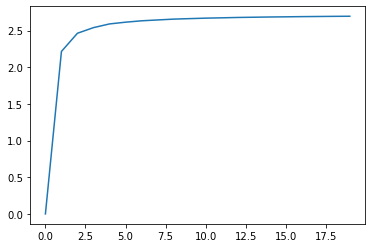

In [17]:
plt.plot(metric_val)

In [26]:
phik = get_phik(unif.evals, basis)
metric.lamk@(phik - 2*ck1)**2

Array(4.7235703, dtype=float32)

In [83]:
np.exp(1)*2

Array(5.4365635, dtype=float32, weak_type=True)

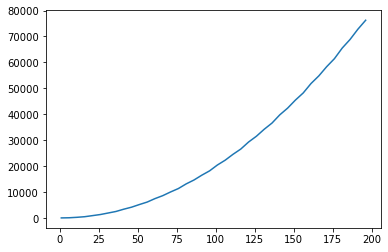

In [79]:
plt.plot(n_basis, metric_val)

In [27]:
out_vals.max()

Array(5.960867, dtype=float32)

In [22]:
def get_metric_val(x1, x2, _n_basis=100):
    basis = BasisFunc([_n_basis]*2)
    metric = ErgodicMetric(basis)
    ck1 = get_ck(x1.reshape((1,-1)), basis, 1, 1) 
    ck2 = get_ck(x2, basis, 1, 1)
    return metric(ck1, ck2)

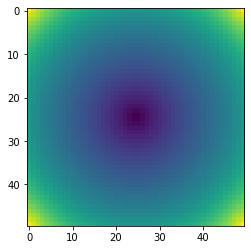

In [49]:
plt.imshow(out_vals.reshape(domain[0].shape))

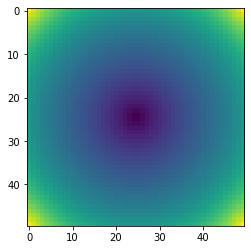

In [51]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [77]:
out_vals.max()

Array(5.960867, dtype=float32)

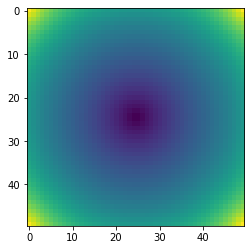

In [73]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [37]:
out_vals.max()

Array(5.960867, dtype=float32)

In [25]:
out_vals = vmap(get_metric_val, in_axes=(0,None,None))(x_vals, np.array([[.5,.5]]), 10)

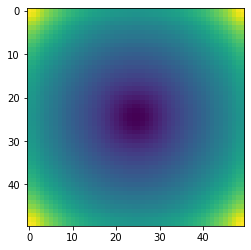

In [75]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [72]:
out_vals

Array([6.638289 , 6.2877855, 5.9528217, ..., 5.952821 , 6.287786 ,
       6.6382885], dtype=float32)

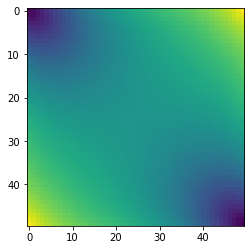

In [68]:
plt.imshow(out_vals.reshape(domain[0].shape))

In [36]:
metric_val

[Array(0., dtype=float32),
 Array(2.2163885, dtype=float32),
 Array(2.4645295, dtype=float32),
 Array(2.541094, dtype=float32),
 Array(2.5916338, dtype=float32),
 Array(2.615362, dtype=float32),
 Array(2.6341941, dtype=float32),
 Array(2.6459067, dtype=float32),
 Array(2.657176, dtype=float32),
 Array(2.6639977, dtype=float32),
 Array(2.6704395, dtype=float32),
 Array(2.6749723, dtype=float32),
 Array(2.6797974, dtype=float32),
 Array(2.6829832, dtype=float32),
 Array(2.686181, dtype=float32),
 Array(2.6885698, dtype=float32),
 Array(2.6912394, dtype=float32),
 Array(2.6930773, dtype=float32),
 Array(2.6949928, dtype=float32),
 Array(2.6964643, dtype=float32),
 Array(2.698155, dtype=float32),
 Array(2.6993499, dtype=float32),
 Array(2.700619, dtype=float32),
 Array(2.7016156, dtype=float32),
 Array(2.7027822, dtype=float32),
 Array(2.7036204, dtype=float32),
 Array(2.7045262, dtype=float32),
 Array(2.705246, dtype=float32),
 Array(2.7060986, dtype=float32),
 Array(2.7067182, dtype=floa

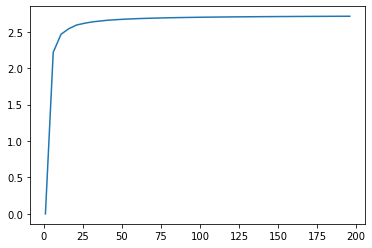

In [37]:
plt.plot(n_basis, metric_val)

In [24]:
domain = np.meshgrid(
    *[
        np.linspace(0,1),
        np.linspace(0,1)
    ]
)
x_vals = np.stack([X.ravel() for X in domain]).T
phi_vals = recon_from_fourier(ck1, basis, basis.k_list, x_vals)

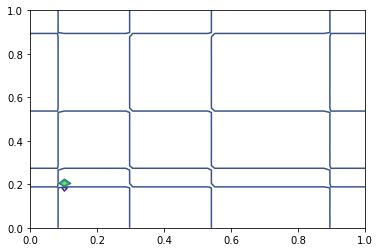

In [22]:
plt.contour(domain[0], domain[1], phi_vals.reshape(domain[0].shape))